<a href="https://colab.research.google.com/github/lazarosgogos/ML-exercises/blob/main/ML_Project_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 10 - Clustering

## Download the dataset

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")

print("Path to dataset files:", path)
!mv $path /content/
!mv 1/dataset.csv ./

## Import libraries

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

## Q1 - Dataframe preprocessing

In [22]:
og_df = pd.read_csv('dataset.csv')
df = og_df.drop(columns=['track_id', 'Unnamed: 0', 'artists', 'album_name', 'track_name'])

enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded = enc.fit_transform(df[["track_genre"]])
encoded_df = pd.DataFrame(encoded, columns=enc.get_feature_names_out(["track_genre"]))

df = df.drop(columns=["track_genre"]).reset_index(drop=True)
df = pd.concat([df, encoded_df], axis=1)
df

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre_acoustic,track_genre_afrobeat,track_genre_alt-rock,track_genre_alternative,track_genre_ambient,track_genre_anime,track_genre_black-metal,track_genre_bluegrass,track_genre_blues,track_genre_brazil,track_genre_breakbeat,track_genre_british,track_genre_cantopop,track_genre_chicago-house,track_genre_children,track_genre_chill,track_genre_classical,track_genre_club,track_genre_comedy,track_genre_country,track_genre_dance,track_genre_dancehall,track_genre_death-metal,track_genre_deep-house,track_genre_detroit-techno,...,track_genre_mpb,track_genre_new-age,track_genre_opera,track_genre_pagode,track_genre_party,track_genre_piano,track_genre_pop,track_genre_pop-film,track_genre_power-pop,track_genre_progressive-house,track_genre_psych-rock,track_genre_punk,track_genre_punk-rock,track_genre_r-n-b,track_genre_reggae,track_genre_reggaeton,track_genre_rock,track_genre_rock-n-roll,track_genre_rockabilly,track_genre_romance,track_genre_sad,track_genre_salsa,track_genre_samba,track_genre_sertanejo,track_genre_show-tunes,track_genre_singer-songwriter,track_genre_ska,track_genre_sleep,track_genre_songwriter,track_genre_soul,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music
0,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
113996,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940

## Q2 - Normalize features
We will use a StandardScaler on the appropriate features: popularity, duration_ms, danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo

In [29]:
scale_cols = [
    'popularity','duration_ms','danceability','energy','loudness',
    'speechiness','acousticness','instrumentalness',
    'liveness','valence','tempo'
]

scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

## Q3 - K-Means

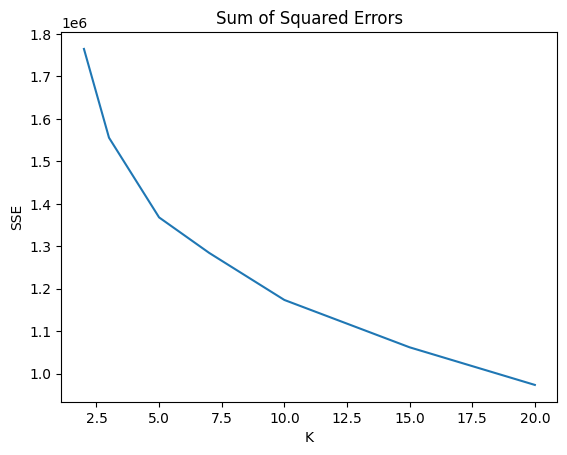

In [31]:
Ks = [2,3,5,7,10,15,20]
results = []
for k in Ks:
  kmean = KMeans(n_clusters=k, )
  kmean.fit(df)
  results.append(kmean.inertia_)

plt.plot(Ks, results)
plt.title("Sum of Squared Errors")
plt.xlabel("K")
plt.ylabel("SSE")
plt.show();

## Q4 - Select best value of `k`
Based on the plot above and the elbow method, the best value of `k` is 10.

In [37]:
k = 10 # best value per elbow method
model = KMeans(n_clusters=k)
model.fit(df)
# print(len(model.labels_))
labels = model.labels_
labels

array([7, 2, 2, ..., 7, 1, 7], dtype=int32)

## Q5 - Calculate main genre per cluster

In [49]:
df["cluster"] = labels

genre_cols = [c for c in df.columns if c.startswith("track_genre")]

dominant_pct = (
    df.groupby("cluster")[genre_cols]
    .mean()
    .max(axis=1) * 100
)

dominant_genre = (
    df.groupby("cluster")[genre_cols]
    .mean()
    .idxmax(axis=1)
    .str.replace("track_genre_", "")
)

result = pd.DataFrame({
    "genre": dominant_genre,
    "percentage": dominant_pct
})

print(result)

                 genre  percentage
cluster                           
0           honky-tonk    4.200557
1                happy    1.765642
2                sleep    4.827423
3            grindcore    2.933399
4               j-idol    1.588715
5               comedy   82.730093
6              romance    2.731209
7                 kids    2.086402
8                sleep   11.990776
9        chicago-house    1.622163


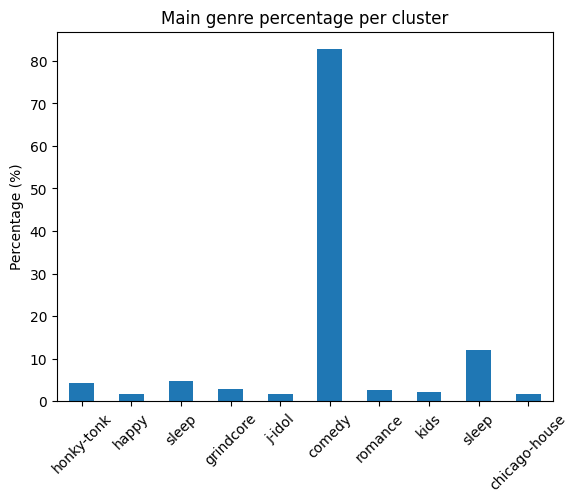

In [48]:
result.plot(
    kind="bar",
    y="percentage",
    legend=False
)
plt.xticks(range(len(result)), result["genre"], rotation=45)
plt.ylabel("Percentage (%)")
plt.title("Main genre percentage per cluster")
plt.xlabel("")
plt.show()

## Q6 - Recommend top-3 similar songs

## Q7 - Recommend top-3 via cosine distance

## Q8 - Use `elbow` for k-group selection

## Q9 - Perform DBScan for clustering

## Q10 - Perform DBScan++ (BONUS)